In [1]:
import numpy as np
import scanpy as sc
import pandas as pd
import seaborn as sns
import logging
import os
import sys
import traceback
import yaml
import torch
import torch.nn as nn
import matplotlib.pyplot as plt
from hydra import initialize, compose
from omegaconf import DictConfig
from tqdm import tqdm
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import confusion_matrix, classification_report
from torch.utils.data import DataLoader, TensorDataset

sys.path.insert(0, "../../../shared_utils")
from experiment_utils import get_forward_model

In [2]:
adata = sc.read_h5ad("/lustre/groups/ml01/workspace/lorenzo.consoli/projects/SFC_cambridge/output/loops/data/loop5/adata_500k_residual.h5ad")

In [3]:
experiments = ["267",
               "268",
               "276", 
               "277", 
               "278"]

adata_cd16mono = adata[adata.obs.experiment_number.isin(experiments)]

In [4]:
adata_cd16mono.obs.experiment_number.unique()

['267', '276', '268', '277', '278']
Categories (5, object): ['267', '268', '276', '277', '278']

## Check comparison CD41a 

In [6]:
cd16_df = {"CD16": adata_cd16mono[:,"CD16"].X.toarray().ravel(), 
             "experiment_number": adata_cd16mono.obs["experiment_number"].values}

In [7]:
cd16_df = pd.DataFrame(cd16_df)

<Axes: xlabel='experiment_number', ylabel='CD16'>

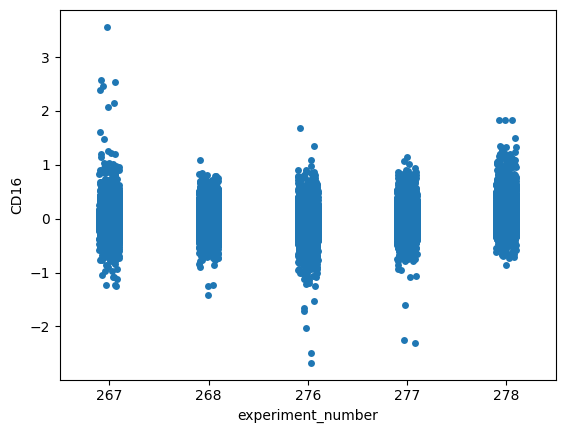

In [8]:
sns.stripplot(cd16_df, x="experiment_number", y="CD16")

# Classification 

In [9]:
with initialize(config_path="../../../inverse/loss_guidance/config", version_base=None):
    config = compose(config_name="run_inverse",
                    overrides=[
                        "paths=bloodplus_fm"
                    ])

ANNOTATION_CFG_FILE = "/lustre/groups/ml01/workspace/lorenzo.consoli/projects/SFC_cambridge/collab-goettgens-SFC/inverse/loss_guidance/config/annotation/default.yaml"
with open(ANNOTATION_CFG_FILE, "r") as fb:
    annotation_cfg = yaml.safe_load(fb)
protocol_cols = annotation_cfg["protocol_columns"]

logger = logging.getLogger(__name__)

forward_model, (
    flow_matching,
    target_prediction_model
) = get_forward_model(config, logger=logger)

In [10]:
# Standardization parameters 
train_adata_g = target_prediction_model.train_data.adata
scatter_params = train_adata_g.uns["X_scatter_params"]
channel_params = train_adata_g.uns["X_channel_params"]
scatter_params.keys(), channel_params.keys()

adata_cd16mono.obs.columns = [
    col.split(' :: ')[-1] if ' :: ' in col else col
    for col in adata_cd16mono.obs.columns
]

In [11]:
X_channel = adata_cd16mono.X
X_channel = (X_channel - channel_params["mean"])/channel_params["std"]
X_scatter = []

for col in config.annotation.scatter_columns:
    col_vals = adata_cd16mono.obs[col].astype(float).values
    X_scatter.append(col_vals)
    
X_scatter = np.stack(X_scatter, axis=1)
X_scatter = (X_scatter - scatter_params["mean"])/scatter_params["std"]

X = np.concatenate(
    (
        X_channel, X_scatter
    ), axis=1
)

print(f"{X_channel.shape=} {X_scatter.shape=}")

X_channel.shape=(125000, 20) X_scatter.shape=(125000, 6)


In [12]:
dataloader = DataLoader(
    torch.utils.data.TensorDataset(torch.from_numpy(X)), 
    batch_size=4026,
    shuffle=False
)

ct_predictions = []

with torch.no_grad():
    for batch in tqdm(dataloader):
        X_batch = batch[0].to(target_prediction_model.device).to(torch.float32)
        y_pred = target_prediction_model.predict(X_batch)["cell_type"].argmax(1)
        ct_predictions.append(y_pred.cpu().detach().numpy())
ct_predictions = np.concatenate(ct_predictions)

100%|██████████| 32/32 [00:04<00:00,  7.51it/s]


In [13]:
# Prepare label encoder
ct_le = LabelEncoder()
ct_values = train_adata_g.obs["cell_type"].values
ct_le.fit(ct_values)
classes = np.array(ct_le.classes_.tolist())

In [14]:
ct_predictions_str = classes[ct_predictions]
adata_cd16mono.obs["cell_type"] = ct_predictions_str

/tmp/ipykernel_2455576/2223418764.py:2: ImplicitModificationWarning: Trying to modify attribute `.obs` of view, initializing view as actual.
  adata_cd16mono.obs["cell_type"] = ct_predictions_str


/tmp/ipykernel_2455576/1005380496.py:2: FutureWarning: Argument `save` is deprecated and will be removed in a future version. Use `sc.pl.plot(show=False).figure.savefig()` instead.
  sc.pl.umap(


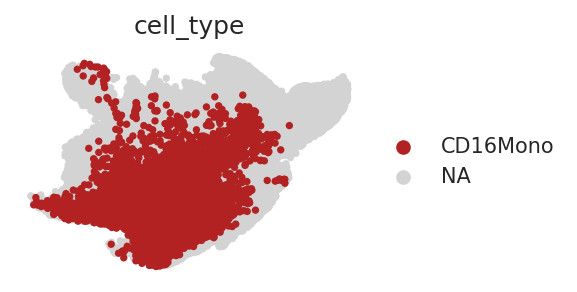

In [25]:
with plt.rc_context({"figure.figsize": (3, 2), "figure.dpi": 150}):
    sc.pl.umap(
        adata_cd16mono,
        color="cell_type",
        s=50,
        groups="CD16Mono",
        palette=["firebrick"],
        frameon=False,
        save="_cd16mono_umap.png",
    )

## Plot cell type props

In [39]:
props_per_exp = {"Exp": [], 
                "mean_cd16": [],
                "prop_cd16mono": [],
                "prop_cd16mono_lin": [],}
for exp in experiments:
    adata_cd16mono_exp = adata_cd16mono[adata_cd16mono.obs["experiment_number"]==exp]
    props = adata_cd16mono_exp.obs.cell_type.value_counts()
    props = props / props.sum()
    props_per_exp["Exp"].append(exp)
    props_per_exp["prop_cd16mono"].append(props["CD16Mono"])
    for ct in classes: 
        if ct not in props.index:
            props[ct] = 0

    props_per_exp["prop_cd16mono_lin"].append(props["CD16Mono"]+props["CD14Mono"])
    cd16_vals = adata_cd16mono_exp[:, "CD16"].X.toarray().ravel()
    top25_thresh = np.quantile(cd16_vals, 0.75)
    props_per_exp["mean_cd16"].append(cd16_vals[cd16_vals >= top25_thresh].mean())

props_per_exp_df = pd.DataFrame(props_per_exp)
props_per_exp_df

,Exp,mean_cd16,prop_cd16mono,prop_cd16mono_lin
0,267,0.200667,0.07832,0.07840
1,268,0.196520,0.08724,0.08732
2,276,0.158675,0.03216,0.03428
3,277,0.183053,0.05096,0.05268
4,278,0.257271,0.06520,0.06556


In [40]:
props_per_exp_df = pd.DataFrame(props_per_exp)

In [41]:
neg_control_row = (
    props_per_exp_df[props_per_exp_df.Exp.isin(["276", "277", "278"])]
    .drop(columns="Exp")
    .apply(pd.to_numeric, errors="coerce")
    .mean()
)
neg_control_row["Exp"] = "negative control"

props_per_exp_df = props_per_exp_df[~props_per_exp_df.Exp.isin(["276", "277", "278"])]

props_per_exp_df = pd.concat(
    [props_per_exp_df, neg_control_row.to_frame().T],
    ignore_index=True
)

props_per_exp_df

,Exp,mean_cd16,prop_cd16mono,prop_cd16mono_lin
0,267,0.200667,0.07832,0.0784
1,268,0.19652,0.08724,0.08732
2,negative control,0.199666,0.04944,0.05084


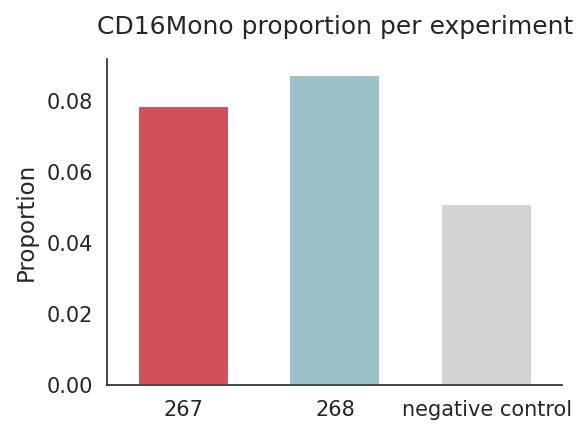

In [42]:
sns.set_style("white")

color_map = {
    "267": "#E63946",
    "268": "#94C7CF",
    "negative control": "lightgray",
}

fig, ax = plt.subplots(figsize=(4, 3), dpi=150)

sns.barplot(
    props_per_exp_df,
    x="Exp",
    y="prop_cd16mono_lin",
    hue="Exp",
    palette=color_map,
    legend=False,
    width=0.6,
    ax=ax
)

ax.set_xlabel("")
ax.set_ylabel("Proportion", fontsize=11)
ax.set_title("CD16Mono proportion per experiment", fontsize=12, pad=12)
sns.despine(ax=ax)
ax.tick_params(axis="both", labelsize=10)

plt.tight_layout()
fig.savefig("prop_cd16mon_lin_barplot.png", dpi=300, bbox_inches="tight")
plt.show()

## Compare to existing protocols

In [43]:
adata_l1 = sc.read_h5ad("/lustre/groups/ml01/workspace/lorenzo.consoli/projects/SFC_cambridge/output/loops/data/loop1/adata_500k.h5ad")
adata_l2 = sc.read_h5ad("/lustre/groups/ml01/workspace/lorenzo.consoli/projects/SFC_cambridge/output/loops/data/loop2/processed/adata_loop2_500k_residual_processed.h5ad")
adata_l2p5 = sc.read_h5ad("/lustre/groups/ml01/workspace/lorenzo.consoli/projects/SFC_cambridge/output/loops/data/loop2/processed/adata_loop2p5_500k_residual_processed.h5ad")
adata_l3 = sc.read_h5ad("/lustre/groups/ml01/workspace/lorenzo.consoli/projects/SFC_cambridge/output/loops/data/loop3/replicate/processed/adata_loop3_500k_residual_processed.h5ad")

In [44]:
adata_concat = sc.concat([adata_l1, adata_l2, adata_l2p5, adata_l3])                       

/home/icb/alessandro.palma/miniconda3/envs/sc_exp_design_12/lib/python3.12/site-packages/anndata/_core/anndata.py:1823: UserWarning: Observation names are not unique. To make them unique, call `.obs_names_make_unique`.
  utils.warn_names_duplicates("obs")
/home/icb/alessandro.palma/miniconda3/envs/sc_exp_design_12/lib/python3.12/site-packages/anndata/_core/anndata.py:1823: UserWarning: Observation names are not unique. To make them unique, call `.obs_names_make_unique`.
  utils.warn_names_duplicates("obs")


In [45]:
adata_concat.obs["experiment_number"] = adata_concat.obs["experiment_number"].astype(str)

In [46]:
for exp in np.unique(adata_concat.obs.experiment_number):
    adata_cd16mono_exp = adata_concat[adata_concat.obs["experiment_number"]==exp]
    props = adata_cd16mono_exp.obs.cell_type.value_counts()
    props = props / props.sum()
    for ct in classes: 
        if ct not in props.index:
            props[ct] = 0
            
    props_per_exp["Exp"].append(exp)
    props_per_exp["prop_cd16mono"].append(props["CD16Mono"])
    props_per_exp["prop_cd16mono_lin"].append(props["CD16Mono"]+props["CD14Mono"])
    cd16_vals = adata_cd16mono_exp[:, "CD16"].X.toarray().ravel()
    top25_thresh = np.quantile(cd16_vals, 0.75)
    props_per_exp["mean_cd16"].append(cd16_vals[cd16_vals >= top25_thresh].mean())

props_per_exp_df = pd.DataFrame(props_per_exp)
props_per_exp_df

,Exp,mean_cd16,prop_cd16mono,prop_cd16mono_lin
0,267,0.200667,0.078320,0.078400
1,268,0.196520,0.087240,0.087320
2,276,0.158675,0.032160,0.034280
3,277,0.183053,0.050960,0.052680
4,278,0.257271,0.065200,0.065560
...,...,...,...,...
142,66,0.035865,0.000252,0.001511
143,67,0.034417,0.000000,0.003136
144,77,0.033833,0.000251,0.002760
145,78,0.026912,0.000000,0.001748


In [47]:
props_per_exp = pd.DataFrame(props_per_exp)

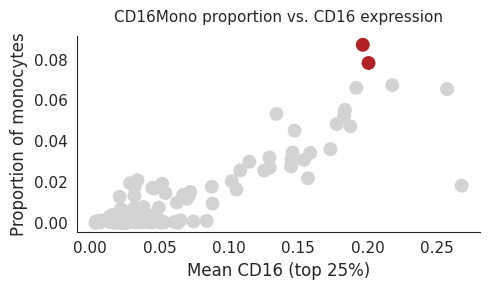

In [52]:
sns.set_style("white")
fig, ax = plt.subplots(figsize=(5, 3))
highlight = ["267",
               "268"]
colors = props_per_exp_df["Exp"].apply(
    lambda e: "firebrick" if e in highlight else "lightgray"
)
sns.scatterplot(
    data=props_per_exp_df,
    x="mean_cd16",
    y="prop_cd16mono_lin",
    s=100,
    edgecolor="none",
    color=colors,
    ax=ax,
)
ax.set_xlabel("Mean CD16 (top 25%)", fontsize=12)
ax.set_ylabel("Proportion of monocytes", fontsize=12)
ax.set_title("CD16Mono proportion vs. CD16 expression", fontsize=11, pad=10)
ax.tick_params(axis="both", labelsize=11)
sns.despine(ax=ax)
plt.tight_layout()
plt.savefig("cd16mono_scatter.png", dpi=300, bbox_inches="tight")
plt.show()